In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [ ]:
#read in csv
sac_data = pd.read_csv("sacstation1.csv")

In [ ]:
#look at first few rows
sac_data.head(5)

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,REPORT_TYPE,SOURCE,CoolingDegreeDaysSeasonToDate,DailyAverageDryBulbTemperature,...,MonthlyMaximumTemperature,MonthlyMeanTemperature,MonthlyMinimumTemperature,MonthlyTotalLiquidPrecipitation,NormalsCoolingDegreeDay,NormalsHeatingDegreeDay,REPORT_TYPE.1,SOURCE.1,Sunrise,Sunset
0,USW00023271,"SACRAMENTO 5 ESE, CA US",38.5552,-121.4183,11.6,1907-01-01T00:00:00,SOD,NaN,NaN,5.9,...,NaN,NaN,NaN,NaN,NaN,NaN,SOD,NaN,723.0,1654.0
1,USW00023271,"SACRAMENTO 5 ESE, CA US",38.5552,-121.4183,11.6,1907-01-01T02:00:00,WBO_F,313.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,WBO_F,313.0,NaN,NaN
2,USW00023271,"SACRAMENTO 5 ESE, CA US",38.5552,-121.4183,11.6,1907-01-01T05:00:00,WBO_F,335.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,WBO_F,335.0,NaN,NaN
3,USW00023271,"SACRAMENTO 5 ESE, CA US",38.5552,-121.4183,11.6,1907-01-01T14:00:00,WBO_F,313.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,WBO_F,313.0,NaN,NaN
4,USW00023271,"SACRAMENTO 5 ESE, CA US",38.5552,-121.4183,11.6,1907-01-01T17:00:00,WBO_F,335.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,WBO_F,335.0,NaN,NaN


In [ ]:
#read in data for larger sacramento area
big_sac_data = pd.read_csv("sacstations.csv")

/var/folders/_r/k4drv0q16vb4s0cfjxzhbc180000gn/T/ipykernel_65336/3312700101.py:1: DtypeWarning: Columns (8,10,11,13,16,19,25,26,27,28,29,31,32,33,34,36,37,42,43,44,45,48,50,52,54,71,72,73,74,75,91,92,96,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,125) have mixed types. Specify dtype option on import or set low_memory=False.
  big_sac_data = pd.read_csv("sacstations.csv")


In [ ]:
#trying to see what the column names are
big_sac_data.columns

Index(['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'DATE',
       'REPORT_TYPE', 'SOURCE', 'BackupDirection', 'BackupDistance',
       ...
       'ShortDurationPrecipitationValue045',
       'ShortDurationPrecipitationValue060',
       'ShortDurationPrecipitationValue080',
       'ShortDurationPrecipitationValue100',
       'ShortDurationPrecipitationValue120',
       'ShortDurationPrecipitationValue150',
       'ShortDurationPrecipitationValue180', 'Sunrise', 'Sunset',
       'WindEquipmentChangeDate'],
      dtype='object', length=126)

In [ ]:
#this allows for all the column names to be seen by displaying as a scrollable element
for col in big_sac_data.columns:
    print(col)

STATION
NAME
LATITUDE
LONGITUDE
ELEVATION
DATE
REPORT_TYPE
SOURCE
BackupDirection
BackupDistance
BackupDistanceUnit
BackupElements
BackupElevation
BackupEquipment
BackupLatitude
BackupLongitude
BackupName
CoolingDegreeDaysSeasonToDate
DailyAverageDewPointTemperature
DailyAverageDryBulbTemperature
DailyAverageRelativeHumidity
DailyAverageSeaLevelPressure
DailyAverageStationPressure
DailyAverageWetBulbTemperature
DailyAverageWindSpeed
DailyCoolingDegreeDays
DailyDepartureFromNormalAverageTemperature
DailyHeatingDegreeDays
DailyMaximumDryBulbTemperature
DailyMinimumDryBulbTemperature
DailyPeakWindDirection
DailyPeakWindSpeed
DailyPrecipitation
DailySnowDepth
DailySnowfall
DailySustainedWindDirection
DailySustainedWindSpeed
DailyWeather
HeatingDegreeDaysSeasonToDate
HourlyAltimeterSetting
HourlyDewPointTemperature
HourlyDryBulbTemperature
HourlyPrecipitation
HourlyPresentWeatherType
HourlyPressureChange
HourlyPressureTendency
HourlyRelativeHumidity
HourlySeaLevelPressure
HourlySkyCondition

In [ ]:
#select columns of relevant interest
selected_big_sac_columns = ["STATION", "NAME", "DATE", "REPORT_TYPE", "BackupName", "HourlyDewPointTemperature", "HourlyDryBulbTemperature", "HourlyPrecipitation", "HourlyVisibility"]

selected_big_sac_data = big_sac_data[selected_big_sac_columns]
selected_big_sac_data

,STATION,NAME,DATE,REPORT_TYPE,BackupName,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility
0,USW00023271,"SACRAMENTO 5 ESE, CA US",1877-07-11T00:00:00,SOD,NaN,NaN,NaN,NaN,NaN
1,USW00023271,"SACRAMENTO 5 ESE, CA US",1877-07-12T00:00:00,SOD,NaN,NaN,NaN,NaN,NaN
2,USW00023271,"SACRAMENTO 5 ESE, CA US",1877-07-13T00:00:00,SOD,NaN,NaN,NaN,NaN,NaN
3,USW00023271,"SACRAMENTO 5 ESE, CA US",1877-07-14T00:00:00,SOD,NaN,NaN,NaN,NaN,NaN
4,USW00023271,"SACRAMENTO 5 ESE, CA US",1877-07-15T00:00:00,SOD,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
3195233,USW00093225,"SACRAMENTO METROPOLITAN AIRPORT, CA US",2026-02-05T09:41:00,FM-16,NaN,8.3,8.9,NaN,3.219
3195234,USW00093225,"SACRAMENTO METROPOLITAN AIRPORT, CA US",2026-02-05T09:53:00,FM-15,NaN,9.4,9.4,NaN,9.656
3195235,USW00093225,"SACRAMENTO METROPOLITAN AIRPORT, CA US",2026-02-05T10:53:00,FM-15,NaN,10.6,12.8,NaN,16.093
3195236,USW00093225,"SACRAMENTO METROPOLITAN AIRPORT, CA US",2026-02-05T11:53:00,FM-15,NaN,11.1,15.6,NaN,16.093


In [27]:
# Look at missing values
missing_data_rows = selected_big_sac_data[selected_big_sac_data.isna().any(axis=1)]
missing_data_rows

,STATION,NAME,DATE,REPORT_TYPE,BackupName,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility
0,USW00023271,"SACRAMENTO 5 ESE, CA US",1877-07-11T00:00:00,SOD,NaN,NaN,NaN,NaN,NaN
1,USW00023271,"SACRAMENTO 5 ESE, CA US",1877-07-12T00:00:00,SOD,NaN,NaN,NaN,NaN,NaN
2,USW00023271,"SACRAMENTO 5 ESE, CA US",1877-07-13T00:00:00,SOD,NaN,NaN,NaN,NaN,NaN
3,USW00023271,"SACRAMENTO 5 ESE, CA US",1877-07-14T00:00:00,SOD,NaN,NaN,NaN,NaN,NaN
4,USW00023271,"SACRAMENTO 5 ESE, CA US",1877-07-15T00:00:00,SOD,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
3195233,USW00093225,"SACRAMENTO METROPOLITAN AIRPORT, CA US",2026-02-05T09:41:00,FM-16,NaN,8.3,8.9,NaN,3.219
3195234,USW00093225,"SACRAMENTO METROPOLITAN AIRPORT, CA US",2026-02-05T09:53:00,FM-15,NaN,9.4,9.4,NaN,9.656
3195235,USW00093225,"SACRAMENTO METROPOLITAN AIRPORT, CA US",2026-02-05T10:53:00,FM-15,NaN,10.6,12.8,NaN,16.093
3195236,USW00093225,"SACRAMENTO METROPOLITAN AIRPORT, CA US",2026-02-05T11:53:00,FM-15,NaN,11.1,15.6,NaN,16.093


In [ ]:
#just looking at hourly visibility
big_sac_data["HourlyVisibility"]

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
            ...  
3195233     3.219
3195234     9.656
3195235    16.093
3195236    16.093
3195237    16.093
Name: HourlyVisibility, Length: 3195238, dtype: object

In [ ]:
#looking at mean/max data because some data is weird
print(big_sac_data["HourlyDryBulbTemperature"].min())
print(big_sac_data["HourlyDryBulbTemperature"].max())
print(big_sac_data["HourlyDryBulbTemperature"].mean())
print(big_sac_data["HourlyDryBulbTemperature"].median())

-51.1
318.0
15.842152616015808
14.6


(array([7.63820e+04, 3.69036e+05, 7.64289e+05, 7.87315e+05, 4.63221e+05,
        2.81598e+05, 1.96968e+05, 6.78930e+04, 6.22900e+03, 4.50000e+01]),
 array([-3. ,  2.3,  7.6, 12.9, 18.2, 23.5, 28.8, 34.1, 39.4, 44.7, 50. ]),
 <BarContainer object of 10 artists>)

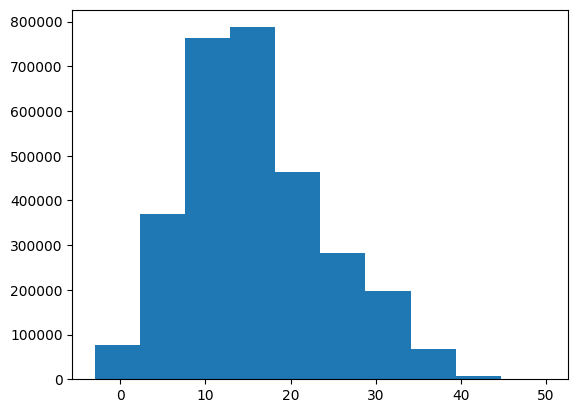

In [ ]:
#histogram of middle values
plt.hist(big_sac_data["HourlyDryBulbTemperature"], range = (-3,50))

(array([  1.,   1.,   5.,   4.,  16.,  21.,  37.,  34.,  70., 174.]),
 array([-10. ,  -9.5,  -9. ,  -8.5,  -8. ,  -7.5,  -7. ,  -6.5,  -6. ,
         -5.5,  -5. ]),
 <BarContainer object of 10 artists>)

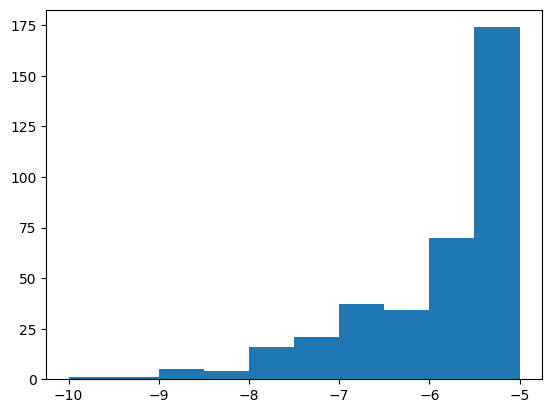

In [ ]:
#histogram of minimum temperatures
plt.hist(selected_big_sac_data["HourlyDryBulbTemperature"], range = (-10,-5))

(array([8., 4., 7., 1., 0., 1., 4., 3., 1., 1.]),
 array([ 50.,  75., 100., 125., 150., 175., 200., 225., 250., 275., 300.]),
 <BarContainer object of 10 artists>)

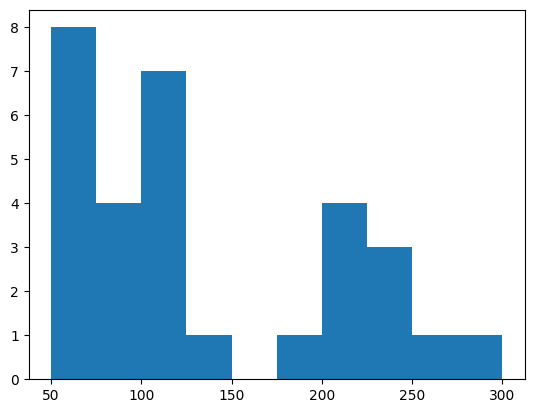

In [ ]:
#histogram of max temperatures
plt.hist(selected_big_sac_data["HourlyDryBulbTemperature"], range = (50,300))

In [ ]:
#what the heck?! Some of these are unreasonable. Let's look at those data points to see wtf is going on
sac_mins = selected_big_sac_data[selected_big_sac_data["HourlyDryBulbTemperature"] < -5]
sac_maxs = selected_big_sac_data[selected_big_sac_data["HourlyDryBulbTemperature"] > 50]

In [49]:
print(sac_maxs)

            STATION                          NAME                 DATE  \
624382  USW00023206  SACRAMENTO MATHER AFB, CA US  2005-12-29T02:58:00   
625822  USW00023206  SACRAMENTO MATHER AFB, CA US  2006-02-23T08:00:00   
631121  USW00023206  SACRAMENTO MATHER AFB, CA US  2006-09-17T10:50:00   
631879  USW00023206  SACRAMENTO MATHER AFB, CA US  2006-10-20T14:45:00   
632366  USW00023206  SACRAMENTO MATHER AFB, CA US  2006-11-11T05:55:00   
633514  USW00023206  SACRAMENTO MATHER AFB, CA US  2006-12-28T12:45:00   
636491  USW00023206  SACRAMENTO MATHER AFB, CA US  2007-05-03T17:45:00   
639635  USW00023206  SACRAMENTO MATHER AFB, CA US  2007-11-18T22:45:00   
640419  USW00023206  SACRAMENTO MATHER AFB, CA US  2007-12-23T19:50:00   
687956  USW00023206  SACRAMENTO MATHER AFB, CA US  2011-02-11T18:45:00   
703312  USW00023206  SACRAMENTO MATHER AFB, CA US  2012-03-10T18:45:00   
703989  USW00023206  SACRAMENTO MATHER AFB, CA US  2012-04-10T15:45:00   
707213  USW00023206  SACRAMENTO MATHER

In [ ]:
#what's up with the airforce base?